In [1]:
import pandas as pd

In [84]:
train =pd.read_csv ("drugsComTrain_raw.csv")
test = pd.read_csv ("drugsComTest_raw.csv")

In [85]:
train.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [86]:
train.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')

In [87]:
train.shape

(161297, 7)

In [88]:
test.shape

(53766, 7)

In [89]:
train.isnull().sum()

uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [90]:
train = train.dropna (subset =["condition"])

In [91]:
test = test.dropna (subset =["condition"])

In [92]:
train.shape

(160398, 7)

In [93]:
train.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


#EDA

In [94]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160398 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     160398 non-null  int64 
 1   drugName     160398 non-null  object
 2   condition    160398 non-null  object
 3   review       160398 non-null  object
 4   rating       160398 non-null  int64 
 5   date         160398 non-null  object
 6   usefulCount  160398 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 9.8+ MB


In [95]:
train.describe()

,uniqueID,rating,usefulCount
count,160398.000000,160398.000000,160398.000000
mean,115957.147309,6.995923,28.097613
std,67015.899492,3.272303,36.457876
min,2.000000,1.000000,0.000000
25%,58065.250000,5.000000,6.000000
50%,115845.500000,8.000000,16.000000
75%,173826.750000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [96]:
#Checking Distribution of Rating

In [97]:
import matplotlib.pyplot as plt


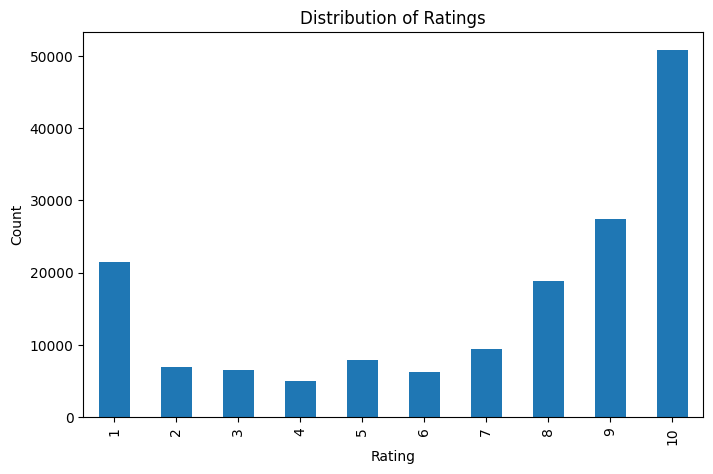

In [98]:
train ["rating"].value_counts().sort_index().plot(
    kind ="bar",
    figsize =(8,5) )
plt.title ("Distribution of Ratings")
plt.xlabel ("Rating")
plt.ylabel ("Count")
plt.show()

In [99]:
#Most Common condition

In [100]:
train["condition"].value_counts().head(10)

condition
Birth Control      28788
Depression          9069
Pain                6145
Anxiety             5904
Acne                5588
Bipolar Disorde     4224
Insomnia            3673
Weight Loss         3609
Obesity             3568
ADHD                3383
Name: count, dtype: int64

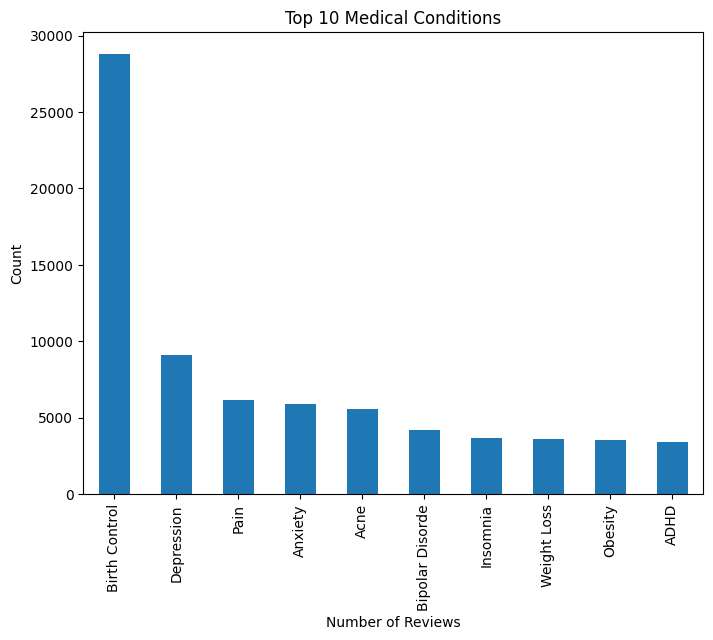

In [101]:
train["condition"].value_counts().head(10).plot(
    kind ="bar",
    figsize=(8,6) )
plt.title ("Top 10 Medical Conditions")
plt.xlabel ("Number of Reviews")
plt.ylabel ("Count")
plt.show()

In [102]:
train["drugName"].value_counts().head(10)

drugName
Levonorgestrel                        3631
Etonogestrel                          3321
Ethinyl estradiol / norethindrone     2750
Nexplanon                             2156
Ethinyl estradiol / norgestimate      2033
Ethinyl estradiol / levonorgestrel    1809
Phentermine                           1538
Sertraline                            1353
Escitalopram                          1287
Mirena                                1242
Name: count, dtype: int64

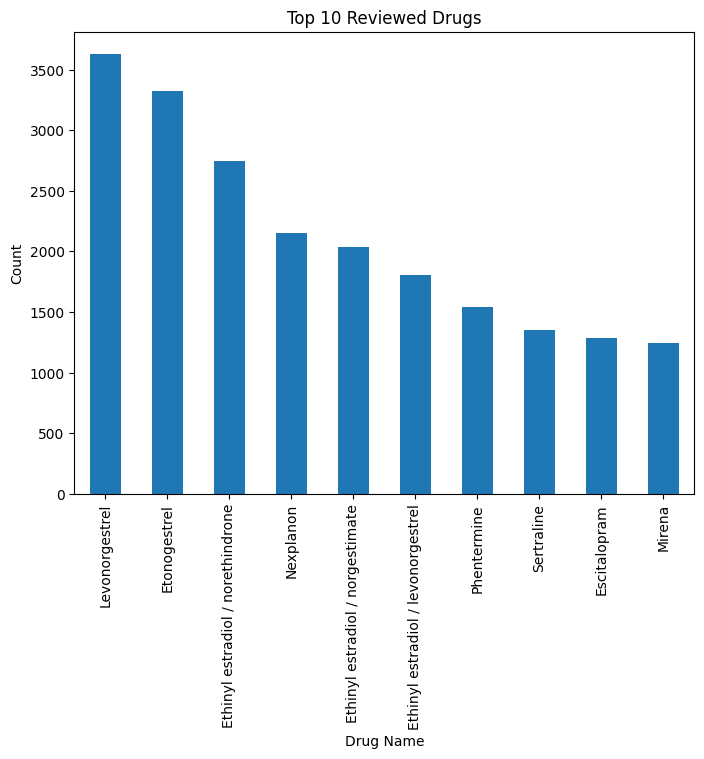

In [103]:
train["drugName"].value_counts().head(10).plot(
    kind ="bar",
    figsize=(8,6) )
plt.title ("Top 10 Reviewed Drugs")
plt.xlabel ("Drug Name")
plt.ylabel ("Count")
plt.show()

#Creating Sentiment for Reviews

In [104]:
train = train [(train ["rating"] >= 7) | (train ["rating"] <=4)]
train ["sentiment"] =train ["rating"].apply(
    lambda x : "Positive" if x >=7 else "Negative")

In [105]:
train ["sentiment"].value_counts() 

sentiment
Positive    106310
Negative     39828
Name: count, dtype: int64

In [106]:
train [["rating","sentiment"]].head()

,rating,sentiment
0,9,Positive
1,8,Positive
3,8,Positive
4,9,Positive
5,2,Negative


In [107]:
train["review"].isnull().sum()

np.int64(0)

In [108]:
train ["review"] =train ["review"].str.lower()

In [109]:
train["review"].head()

0    "it has no side effect, i take it in combinati...
1    "my son is halfway through his fourth week of ...
3    "this is my first time using any form of birth...
4    "suboxone has completely turned my life around...
5    "2nd day on 5mg started to work with rock hard...
Name: review, dtype: object

In [110]:
print (train["review"].iloc[0])

"it has no side effect, i take it in combination of bystolic 5 mg and fish oil"


['zz' 'zz zz' 'zzz' 'zzz zzz' 'zzzz' 'zzzz zz' 'zzzzz' 'zzzzzzzz']


#Remove Punctuations

In [113]:
import re
train ["review"] =train ["review"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x) )

#Tokenization +stopwords+Lemmatization

In [114]:
import nltk

nltk.download ("punkt")
nltk.download ("punkt_tab")
nltk.download("stopwords")
nltk.download ("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lapshop\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lapshop\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lapshop\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lapshop\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\lapshop\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [116]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [117]:
stop_words =set (stopwords.words ("english"))
lemmatizer =WordNetLemmatizer ()

#Cleaning

In [118]:
def clean_text (text):
    text = str(text).lower()
    text =re.sub(r'[^a-zA-Z\s]', ' ',text)
    tokens  = word_tokenize (text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize (word) for word in tokens]
    return " ".join(tokens)

In [120]:
train ["clean_review "] = train["review"].apply(clean_text)

In [121]:
print (train ["review"].iloc[4])
print("____________")
print(train["clean_review "].iloc[4])

nd day on mg started to work with rock hard erections however experianced headache lower bowel preassure rd day erections would wake me up amp hurt legankles aches   severe lower bowel preassure like you need to go  but cant enjoyed the initial rockhard erections but not at these side effects or  for months supply im  amp work out xs a week not worth side effects
____________
nd day mg started work rock hard erection however experianced headache lower bowel preassure rd day erection would wake amp hurt legankles ache severe lower bowel preassure like need go cant enjoyed initial rockhard erection side effect month supply im amp work x week worth side effect


In [122]:
print (train.columns)

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount', 'sentiment', 'clean_review '],
      dtype='object')


In [123]:
train["clean_review "].head()

0    side effect take combination bystolic mg fish oil
1    son halfway fourth week intuniv became concern...
3    first time using form birth control im glad we...
4    suboxone completely turned life around feel he...
5    nd day mg started work rock hard erection howe...
Name: clean_review , dtype: object

#Using TfidfVectorizer that returns a Scipy CSR sparse matrix , avoiding converting sparse matrices to dense arrays , reduce RAM usage

In [124]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [126]:
tfidf = TfidfVectorizer (max_features =5000, ngram_range =(1,2))
x = tfidf.fit_transform (train ["clean_review "])
y = train["sentiment"]

In [127]:
print (x.shape)

(146138, 5000)


In [128]:
print(tfidf.get_feature_names_out())

['abdomen' 'abdominal' 'abdominal pain' ... 'zombie' 'zyprexa' 'zyrtec']


In [129]:
x_train , x_test ,y_train , y_test=train_test_split(
    x,
    y,
    test_size =0.2,
    random_state =42,
    stratify = y)

In [130]:
print (y_train.value_counts())
print (y_test.value_counts())

sentiment
Positive    85048
Negative    31862
Name: count, dtype: int64
sentiment
Positive    21262
Negative     7966
Name: count, dtype: int64


#Naive Bayes Training

In [131]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train , y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[31862.,85048.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.3 ,-0.32]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](2,)","['Negative','Positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[23.73,66.77,43.98,...,54.69,12.36,13.32], [28.86,71.35,40.12,...,67.31,53.53,33.35]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-8.91,-7.9 ,-8.31,...,-8.09,-9.52,-9.45], [-9.7 ,-8.81,-9.38,...,-8.87,-9.09,-9.56]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


#Model Evaluation

In [132]:
from sklearn.metrics import accuracy_score, classification_report

y_pred =model.predict (x_test)

In [148]:
print ("nb_acc: " ,accuracy_score (y_test ,y_pred))
print (classification_report (y_test , y_pred))

nb_acc:  0.8251676474613384
              precision    recall  f1-score   support

    Negative       0.84      0.44      0.58      7966
    Positive       0.82      0.97      0.89     21262

    accuracy                           0.83     29228
   macro avg       0.83      0.71      0.73     29228
weighted avg       0.83      0.83      0.81     29228



In [154]:
nb_acc = accuracy_score (y_test ,y_pred)

In [155]:
nb_acc

0.8251676474613384

In [134]:
train["sentiment"].value_counts()

sentiment
Positive    106310
Negative     39828
Name: count, dtype: int64

In [135]:
#Model Comparison

In [145]:
from sklearn.svm import LinearSVC
svm =LinearSVC()
svm.fit (x_train, y_train)
y_pred_svm = svm.predict(x_test)

print("svm_acc:" ,accuracy_score(y_test, y_pred_svm))
print(classification_report (y_test ,y_pred_svm))

svm_acc: 0.8670795127959491
              precision    recall  f1-score   support

    Negative       0.78      0.71      0.74      7966
    Positive       0.90      0.93      0.91     21262

    accuracy                           0.87     29228
   macro avg       0.84      0.82      0.83     29228
weighted avg       0.86      0.87      0.87     29228



In [143]:
from sklearn.linear_model import LogisticRegression
lr =LogisticRegression (max_iter= 1000)
lr.fit (x_train, y_train)
y_pred_lr = lr.predict(x_test)

print("lr_acc:" ,accuracy_score(y_test, y_pred_lr))
print(classification_report (y_test ,y_pred_lr))

lr_acc: 0.8669084439578486
              precision    recall  f1-score   support

    Negative       0.80      0.68      0.73      7966
    Positive       0.89      0.94      0.91     21262

    accuracy                           0.87     29228
   macro avg       0.84      0.81      0.82     29228
weighted avg       0.86      0.87      0.86     29228



#Confusion MAtrix

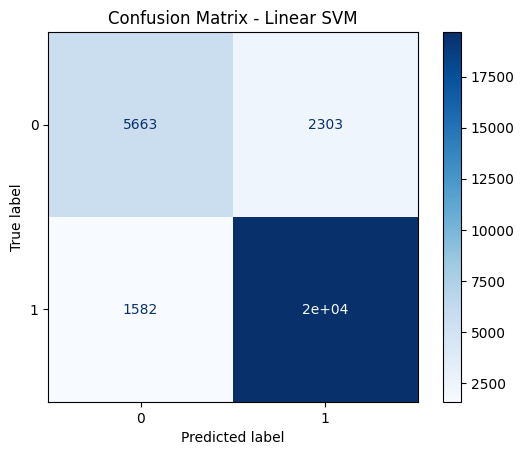

In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [158]:
review = "This medicine worked very well. I had no side effects."

clean = clean_text(review)

vector = tfidf.transform([clean])

prediction = svm.predict(vector)

print("Prediction:", prediction[0])

Prediction: Positive


In [159]:
review = "This medicine caused severe headache and nausea. I will never use it again."

clean = clean_text(review)

vector = tfidf.transform([clean])

prediction = svm.predict(vector)

print("Prediction:", prediction[0])

Prediction: Negative


Executive Summary

This project developed a Natural Language Processing (NLP) pipeline to classify drug reviews into Positive and Negative sentiments.

The workflow included text preprocessing (tokenization, stop-word removal, lemmatization), TF-IDF vectorization, and machine learning model training.

Three classifiers were evaluated:
- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

Among all models, Linear SVM achieved the best overall performance and was selected as the final model.

The project demonstrates how NLP techniques can automatically analyze patient feedback and support healthcare organizations in understanding patient satisfaction and medication experience.

Business Recommendations

• Use sentiment analysis to monitor patient feedback automatically.

• Identify medications with consistently negative reviews for further investigation.

• Help healthcare providers understand patient satisfaction trends.

• Support pharmaceutical companies in post-market surveillance.

• Integrate sentiment analysis into healthcare analytics dashboards for real-time monitoring.